## **Extracting RNA Modification Information**

Welcome to the mini-course: Processing RNA modification Information from Nanopore Direct RNA Sequencing. Our goal is for you to understand the basic concepts, file types, and pipeline in order to extract modification data from sequencing files.  
****Before We Begin. First save a copy of this notebook ('File' 'save copy to my drive). Go to the copy version, and delete the original version. This will allow you to make edits in the copy version. Next please open this link to a google drive folder. Once you open it, you need to move it to 'My Drive'. It may be there already, but it may also be in 'shared with me'. Move the entire folder of "Colab_bio_class" into 'My Drive' ** https://drive.google.com/drive/folders/18nheGDBJg2vPeGi9IIlfvX40HOVU2wUb?usp=sharing
After this follow #1a,1b below to confirm that you have access to the correct files :)

Bienvenido al minicurso: **Procesamiento de información sobre modificaciones de ARN a partir de la secuenciación directa de ARN con Nanopore**. Nuestro objetivo es que comprendas los conceptos básicos, los tipos de archivos y el flujo de trabajo (pipeline) para poder extraer datos de modificaciones a partir de los archivos de secuenciación.

**Antes de comenzar.** Primero, guarda una copia de este cuaderno (*"File" → "Save copy to my Drive"*). Ve a la versión copiada y elimina la versión original. Esto te permitirá realizar ediciones en la copia. A continuación, abre este enlace a una carpeta de Google Drive. Una vez que la abras, debes moverla a **"My Drive"**. Es posible que ya esté allí, pero también puede encontrarse en **"Shared with me"**. Mueve la carpeta completa llamada **"Colab_bio_class"** a **"My Drive"**.

**https://drive.google.com/drive/folders/18nheGDBJg2vPeGi9IIlfvX40HOVU2wUb?usp=sharing**

Después de esto, sigue los pasos **#1a** y **#1b** que aparecen a continuación para confirmar que tienes acceso a los archivos correctos. :)


**1. Install Programs**

***1a. Connect your google Drive to this notebook***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


***1b. Verify Your Access to the Files using !ls command :***

In [ ]:
# Confirm Access to the Drive and Files
!ls /content/drive/MyDrive/Colab_bio_class/

Arabidopsis_annotations.gff  Replicate_1.bed  Replicate_3.bam
Pratical_Nanopore.pptx	     Replicate_2.bai  subset_bams_100k.sh
Replicate_1.bai		     Replicate_2.bam  tair10chr.fasta.fa
Replicate_1.bam		     Replicate_3.bai  tair10chr.fasta.fa.fai


**1. Continued... Install the Remaining Packages**

In [ ]:
%%bash
set -euo pipefail

FILENAME="modkit.tar.gz"
URL="https://github.com/nanoporetech/modkit/releases/download/v0.6.4/modkit_v0.6.4_u16_x86_64.tar.gz"

cd /content
wget -q "$URL" -O "$FILENAME"

tar -xzf "$FILENAME"

# Dynamically find the extracted directory, which starts with 'dist_modkit'
EXTRACTED_DIR=$(ls -d /content/dist_modkit* | head -n 1 | xargs basename)

MODKIT="/content/${EXTRACTED_DIR}/modkit"
chmod +x "$MODKIT"
cp "$MODKIT" /usr/local/bin/modkit

modkit --version

modkit 0.6.4


In [ ]:
!modkit -help

Modkit is a bioinformatics tool for working with modified bases from Oxford
Nanopore

Usage: modkit <COMMAND>

Commands:
  pileup          Tabulates base modification calls across genomic positions.
                  This command produces a bedMethyl formatted file. Schema and
                  description of fields can be found in the README
  extract         Extract read-level base modification information from a modBAM
                  into a tab-separated values table
  dmr             Perform DMR test on a set of regions. Output a BED file of
                  regions with the score column indicating the magnitude of the
                  difference. Find the schema and description of fields can in
                  the README as well as a description of the model and method.
                  See subcommand help for additional details
  pileup-hemi     Tabulates double-stranded base modification patters (such as
                  hemi-methylation) across genomic motif positions.

In [ ]:
#INSTALL Samtools
!apt-get -qq update
!apt-get -qq install samtools
!samtools --version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libhtscodecs2:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libhtscodecs2_1.1.1-3_amd64.deb ...
Unpacking libhtscodecs2:amd64 (1.1.1-3) ...
Selecting previously unselected package libhts3:amd64.
Preparing to unpack .../libhts3_1.13+ds-2build1_amd64.deb ...
Unpacking libhts3:amd64 (1.13+ds-2build1) ...
Selecting previously unselected package samtools.
Preparing to unpack .../samtools_1.13-4_amd64.deb ...
Unpacking samtools (1.13-4) ...
Setting up libhtscodecs2:amd64 (1.1.1-3) ...
Setting up libhts3:amd64 (1.13+ds-2build1) ...
Setting up samtools (1.13-4) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.13) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbmallo

In [ ]:
!apt-get -qq install r-base
!Rscript -e 'install.packages("data.table", repos="https://cloud.r-project.org")'
!pip install -q rpy2
%load_ext rpy2.ipython

(Reading database ... 118342 files and directories currently installed.)
Preparing to unpack .../r-base-core_4.6.1-4.2204.0_amd64.deb ...
Unpacking r-base-core (4.6.1-4.2204.0) over (4.6.0-4.2204.0) ...
Preparing to unpack .../r-base_4.6.1-4.2204.0_all.deb ...
Unpacking r-base (4.6.1-4.2204.0) over (4.6.0-4.2204.0) ...
Preparing to unpack .../r-recommended_4.6.1-4.2204.0_all.deb ...
Unpacking r-recommended (4.6.1-4.2204.0) over (4.6.0-4.2204.0) ...
Setting up r-base-core (4.6.1-4.2204.0) ...
Installing new version of config file /etc/R/Makeconf ...
Setting up r-recommended (4.6.1-4.2204.0) ...
Setting up r-base (4.6.1-4.2204.0) ...
Processing triggers for hicolor-icon-theme (0.17-2) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for mailcap (3.70+nmu1ubuntu1) ...
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/data.table_1.18.4.tar.gz'
Content type 'application/x-gzip' length 60

In [ ]:
%%R
if (!requireNamespace("BiocManager", quietly=TRUE))
  install.packages("BiocManager", repos="https://cloud.r-project.org")
BiocManager::install("GenomicRanges", ask=FALSE, update=FALSE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/BiocManager_1.30.27.tar.gz'
Content type 'application/x-gzip' length 752490 bytes (734 KB)
downloaded 734 KB


The downloaded source packages are in
	‘/tmp/RtmpymFxub/downloaded_packages’
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)
Installing package(s) 'BiocVersion', 'GenomicRanges'
also installing the dependencies ‘BiocGenerics’, ‘S4Vectors’, ‘IRanges’, ‘Seqinfo’

trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/BiocGenerics_0.58.1.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/S4Vectors_0.50.1.tar.gz'
trying URL 'https://bioconductor.org/packages/3.23/bioc/src/contrib/IRanges_2.46.0.tar.gz'

**2. Verify Access To Teaching Files**

In [ ]:
!ls /content/drive/MyDrive/Colab_bio_class/

Arabidopsis_annotations.gff  Replicate_1.bed  Replicate_3.bam
Pratical_Nanopore.pptx	     Replicate_2.bai  subset_bams_100k.sh
Replicate_1.bai		     Replicate_2.bam  tair10chr.fasta.fa
Replicate_1.bam		     Replicate_3.bai  tair10chr.fasta.fa.fai


**3. Visualize .Bam File - Introduction to .Bam Files**

In [ ]:
BAM = "/content/drive/MyDrive/Colab_bio_class/Replicate_3.bam"

!samtools view "{BAM}" | head -n 5

dc28ef9f-8b7b-44ec-bf03-2f06ecf83f60	0	Chr1	30949	60	1S134M1D30M1D12M1D28M10S	*	0	0	TGGGTAAGAGTTAATACGAGCGATAGAGGATGGACCGATGAGTGTATTGGCGAGCCAATGCCGAGTGTTAAGAAAGCTAAGGATTCAGCTGCGGTTCTTCTACTTGAGCTTTTAAATAAAACTTTTTCTTGATTCTTTACTCTCTTCAACGAGATGTAGTCATTAACTTTAAACCTTAAACCATAGTGGTTGTAGTGTTTTAATTAAAAAAAAAA	&'),-.347:<@BBDDCCCBAA@@ABBAAAA@?>>?@AAAAA@@ABEB@@@BCBA.<<<==>@BBC4956=DDBAAAAB@AA@@A@AA@?=>>6999CCAAA@??>?@GHFDBCCCEEEA?@@??8801:,((*65573434523::9999::877776642....323786310///.-,,,,,,,,+++*)(((((((('((('*,..////.	NM:i:4	ms:i:192	AS:i:192	nn:i:0	ts:A:+	tp:A:P	cm:i:48	s1:i:185	s2:i:0	de:f:0.0193	rl:i:14	qs:f:15.1243	du:f:3.791	ns:i:15164	ts:i:3650	mx:i:4	ch:i:657	st:Z:2025-01-23T04:55:04.645+00:00	rn:i:6465	fn:Z:PBC48523_a190f108_10aa789d_31.pod5	sm:f:777.445	sd:f:116.091	sv:Z:pa	dx:i:0	RG:Z:10aa789d3a5cae7280dd7ff1383c1befe48983c0_rna004_130bps_hac@v5.1.0	mv:B:c,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0

**4. Extract Modification Information: Use Modkit Program to Generate Bed.12**

***4a. Replicate_1***

In [ ]:
  !modkit pileup \
  --mod-threshold a:0.99 \
  --mod-threshold 17802:0.99 \
  --mod-threshold 17596:0.99 \
  --mod-threshold 69426:0.99 \
  --mod-threshold 19228:0.99 \
  --mod-threshold m:0.99 \
  --mod-threshold 19229:0.99 \
  --mod-threshold 19227:0.99 \
  --filter-threshold A:0.8 \
  --modified-bases A:a A:17802 A:17596 A:69426 A:19228 A:19229 A:19227 C:m \
  --ref /content/drive/MyDrive/Colab_bio_class/tair10chr.fasta.fa \
  /content/drive/MyDrive/Colab_bio_class/Replicate_1.bam \
  /content/Replicate_1.pileup.bed12

> parsed user-input threshold 0.99 for mod-code m
> parsed user-input threshold 0.99 for mod-code 69426
> parsed user-input threshold 0.99 for mod-code 17596
> parsed user-input threshold 0.99 for mod-code a
> parsed user-input threshold 0.99 for mod-code 19227
> parsed user-input threshold 0.99 for mod-code 17802
> parsed user-input threshold 0.99 for mod-code 19229
> parsed user-input threshold 0.99 for mod-code 19228
> discarded 0 contigs with zero aligned reads
> parsed 8 base modification(s). Base modifications other than 'A:17596,A:17802,A:19227,A:19228,A:19229,A:69426,A:a,C:m' will be counted as 'N_other'.
> adding single-base motif: 'A 0'
> adding single-base motif: 'C 0'
> 0 B written to output: Replicate_1.pileup.bed12 [0 B/s]                       > using user-specified filter threshold 0.8 (qual: 204) for A
> no default pass threshold was provided, so base modifications at primary sequence bases other than A will not be filtered
> using optimized workers for all-context
> 0

In [ ]:
# Visualize the result: Always Verify the output!
!head /content/Replicate_1.pileup.bed12

Chr1	5653	5654	17596	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5653	5654	17802	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5653	5654	19227	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5653	5654	19228	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5653	5654	19229	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5653	5654	69426	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5653	5654	a	1	+	5653	5654	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5654	5655	17596	1	+	5654	5655	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5654	5655	17802	1	+	5654	5655	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5654	5655	19227	1	+	5654	5655	255,0,0	1	0.00	0	1	0	0	0	0	0


***4b. Replicate_2***

In [ ]:
 !modkit pileup \
  --mod-threshold a:0.99 \
  --mod-threshold 17802:0.99 \
  --mod-threshold 17596:0.99 \
  --mod-threshold 69426:0.99 \
  --mod-threshold 19228:0.99 \
  --mod-threshold m:0.99 \
  --mod-threshold 19229:0.99 \
  --mod-threshold 19227:0.99 \
  --filter-threshold A:0.8 \
  --modified-bases A:a A:17802 A:17596 A:69426 A:19228 A:19229 A:19227 C:m \
  --ref /content/drive/MyDrive/Colab_bio_class/tair10chr.fasta.fa \
  /content/drive/MyDrive/Colab_bio_class/Replicate_2.bam \
  /content/Replicate_2.pileup.bed12

> parsed user-input threshold 0.99 for mod-code 19227
> parsed user-input threshold 0.99 for mod-code a
> parsed user-input threshold 0.99 for mod-code 69426
> parsed user-input threshold 0.99 for mod-code 19228
> parsed user-input threshold 0.99 for mod-code m
> parsed user-input threshold 0.99 for mod-code 17802
> parsed user-input threshold 0.99 for mod-code 17596
> parsed user-input threshold 0.99 for mod-code 19229
> discarded 0 contigs with zero aligned reads
> parsed 8 base modification(s). Base modifications other than 'A:17596,A:17802,A:19227,A:19228,A:19229,A:69426,A:a,C:m' will be counted as 'N_other'.
> adding single-base motif: 'A 0'
> adding single-base motif: 'C 0'
> 0 B written to output: Replicate_2.pileup.bed12 [0 B/s]                       > using user-specified filter threshold 0.8 (qual: 204) for A
> no default pass threshold was provided, so base modifications at primary sequence bases other than A will not be filtered
> using optimized workers for all-context
> 0

In [ ]:
# Verify Replicate_2
!head /content/Replicate_2.pileup.bed12

Chr1	5297	5298	17596	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5297	5298	17802	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5297	5298	19227	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5297	5298	19228	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5297	5298	19229	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5297	5298	69426	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5297	5298	a	1	+	5297	5298	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5301	5302	17596	1	+	5301	5302	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5301	5302	17802	1	+	5301	5302	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	5301	5302	19227	1	+	5301	5302	255,0,0	1	0.00	0	1	0	0	0	0	0


***4c. Replicate_3***

In [ ]:
 !modkit pileup \
  --mod-threshold a:0.99 \
  --mod-threshold 17802:0.99 \
  --mod-threshold 17596:0.99 \
  --mod-threshold 69426:0.99 \
  --mod-threshold 19228:0.99 \
  --mod-threshold m:0.99 \
  --mod-threshold 19229:0.99 \
  --mod-threshold 19227:0.99 \
  --filter-threshold A:0.8 \
  --modified-bases A:a A:17802 A:17596 A:69426 A:19228 A:19229 A:19227 C:m \
  --ref /content/drive/MyDrive/Colab_bio_class/tair10chr.fasta.fa \
  /content/drive/MyDrive/Colab_bio_class/Replicate_3.bam \
  /content/Replicate_3.pileup.bed12

> parsed user-input threshold 0.99 for mod-code 19227
> parsed user-input threshold 0.99 for mod-code 69426
> parsed user-input threshold 0.99 for mod-code m
> parsed user-input threshold 0.99 for mod-code 17596
> parsed user-input threshold 0.99 for mod-code a
> parsed user-input threshold 0.99 for mod-code 17802
> parsed user-input threshold 0.99 for mod-code 19228
> parsed user-input threshold 0.99 for mod-code 19229
> discarded 0 contigs with zero aligned reads
> parsed 8 base modification(s). Base modifications other than 'A:17596,A:17802,A:19227,A:19228,A:19229,A:69426,A:a,C:m' will be counted as 'N_other'.
> adding single-base motif: 'A 0'
> adding single-base motif: 'C 0'
> 0 B written to output: Replicate_3.pileup.bed12 [0 B/s]                       > using user-specified filter threshold 0.8 (qual: 204) for A
> no default pass threshold was provided, so base modifications at primary sequence bases other than A will not be filtered
> using optimized workers for all-context
> 0

In [ ]:
#Verify the results
!head /content/Replicate_3.pileup.bed12

Chr1	30952	30953	17596	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30952	30953	17802	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30952	30953	19227	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30952	30953	19228	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30952	30953	19229	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30952	30953	69426	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30952	30953	a	1	+	30952	30953	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30953	30954	17596	1	+	30953	30954	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30953	30954	17802	1	+	30953	30954	255,0,0	1	0.00	0	1	0	0	0	0	0
Chr1	30953	30954	19227	1	+	30953	30954	255,0,0	1	0.00	0	1	0	0	0	0	0


**5. Filtering Modification Data: Choosing Minimum Criteria**

In [ ]:
%%R
library(data.table)


# =============================================================================
# FILTERING PARAMETERS - ADJUST THESE AS NEEDED
# =============================================================================
min_reads <- 10          # Minimum average total read coverage.
min_mod_reads <- 2       # Minimum average modification reads for m6A
min_mod_percent <- 5     # Minimum average modification percentage (0 = no % filter)



# =============================================================================
# PATHS (Colab)
# =============================================================================
rep_files <- c(
  "/content/Replicate_1.pileup.bed12",
  "/content/Replicate_2.pileup.bed12",
  "/content/Replicate_3.pileup.bed12"
)
output_file <- "/content/m6A_filtered_3reps.bed12"

# =============================================================================
# HELPERS
# =============================================================================
load_m6a_replicate <- function(path) {
  cat("Loading:", path, "\n")
  dt <- fread(
    path,
    skip = 1,
    header = FALSE,
    sep = "\t",
    select = c(1, 2, 3, 4, 6, 10, 11, 12),
    showProgress = TRUE
  )
  setnames(dt, c("chr", "start", "end", "base", "strand", "total_reads", "pct_mod", "mod_reads"))
  dt[, start := as.integer(start)]
  dt[, end := as.integer(end)]
  dt[, total_reads := as.numeric(total_reads)]
  dt[, pct_mod := as.numeric(pct_mod)]
  dt[, mod_reads := as.numeric(mod_reads)]

  # Keep m6A rows (modkit code starts with "a")
  dt <- dt[grepl("^a", base)]
  dt[, base := "a"]
  unique(dt, by = c("chr", "start", "end", "base", "strand"))
}

# =============================================================================
# LOAD 3 REPLICATES + MERGE (sites present in all 3)
# =============================================================================
rep1 <- load_m6a_replicate(rep_files[1])
cat("  Rep1 m6A sites:", nrow(rep1), "\n")

rep2 <- load_m6a_replicate(rep_files[2])
cat("  Rep2 m6A sites:", nrow(rep2), "\n")

rep3 <- load_m6a_replicate(rep_files[3])
cat("  Rep3 m6A sites:", nrow(rep3), "\n")

merged12 <- merge(
  rep1, rep2,
  by = c("chr", "start", "end", "base", "strand"),
  suffixes = c(".R1", ".R2")
)
merged <- merge(
  merged12, rep3,
  by = c("chr", "start", "end", "base", "strand"),
  suffixes = c("", ".R3")
)
setnames(
  merged,
  c("total_reads", "pct_mod", "mod_reads"),
  c("total_reads.R3", "pct_mod.R3", "mod_reads.R3")
)

merged[, avg_total_reads := rowMeans(.SD), .SDcols = c("total_reads.R1", "total_reads.R2", "total_reads.R3")]
merged[, avg_mod_reads   := rowMeans(.SD), .SDcols = c("mod_reads.R1", "mod_reads.R2", "mod_reads.R3")]
merged[, avg_pct_mod     := rowMeans(.SD), .SDcols = c("pct_mod.R1", "pct_mod.R2", "pct_mod.R3")]

cat("Shared m6A sites across all 3 replicates:", nrow(merged), "\n")

# =============================================================================
# FILTER ON AVERAGES
# =============================================================================
filtered <- merged[avg_mod_reads >= min_mod_reads & avg_total_reads >= min_reads]
if (min_mod_percent > 0) {
  filtered <- filtered[avg_pct_mod >= min_mod_percent]
}
filtered <- unique(filtered)

out <- filtered[, .(
  chr, start, end, base, strand,
  total_reads.R1, pct_mod.R1, mod_reads.R1,
  total_reads.R2, pct_mod.R2, mod_reads.R2,
  total_reads.R3, pct_mod.R3, mod_reads.R3,
  avg_mod_reads, avg_pct_mod, avg_total_reads
)]
setnames(out, c(
  "chr", "start", "end", "base", "strand",
  "total_read_R1", "perct_mod_R1", "mod_read_R1",
  "total_read_R2", "perct_mod_R2", "mod_read_R2",
  "total_read_R3", "perct_mod_R3", "mod_read_R3",
  "AVG_mod_read", "AVG_perct_mod", "AVG_total_read"
))

numeric_cols <- c(
  "total_read_R1", "perct_mod_R1", "mod_read_R1",
  "total_read_R2", "perct_mod_R2", "mod_read_R2",
  "total_read_R3", "perct_mod_R3", "mod_read_R3",
  "AVG_mod_read", "AVG_perct_mod", "AVG_total_read"
)
out[, (numeric_cols) := lapply(.SD, function(x) round(x, 4)), .SDcols = numeric_cols]

fwrite(out, output_file, sep = "\t", quote = FALSE)

cat("\nFilter settings:\n")
cat("  min_reads       =", min_reads, "\n")
cat("  min_mod_reads   =", min_mod_reads, "\n")
cat("  min_mod_percent =", min_mod_percent, "\n")
cat("\nSites after filtering:", nrow(out), "\n")
cat("Written to:", output_file, "\n")


Loading: /content/Replicate_1.pileup.bed12 
  Rep1 m6A sites: 1328054 
Loading: /content/Replicate_2.pileup.bed12 
  Rep2 m6A sites: 1300114 
Loading: /content/Replicate_3.pileup.bed12 
  Rep3 m6A sites: 943743 
Shared m6A sites across all 3 replicates: 340197 

Filter settings:
  min_reads       = 10 
  min_mod_reads   = 2 
  min_mod_percent = 5 

Sites after filtering: 1832 
Written to: /content/m6A_filtered_3reps.bed12 


data.table 1.18.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following object is masked from ‘package:base’:

    %notin%

|--------------------------------------------------|
|==================================================|
|--------------------------------------------------|
|==================================================|
|--------------------------------------------------|
|==================================================|


In [ ]:
#Verify the Filtered File
!head -10 /content/m6A_filtered_3reps.bed12

chr	start	end	base	strand	total_read_R1	perct_mod_R1	mod_read_R1	total_read_R2	perct_mod_R2	mod_read_R2	total_read_R3	perct_mod_R3	mod_read_R3	AVG_mod_read	AVG_perct_mod	AVG_total_read
Chr1	50112	50113	a	-	16	18.75	3	21	9.52	2	19	10.53	2	2.3333	12.9333	18.6667
Chr1	50138	50139	a	-	29	55.17	16	51	62.75	32	32	62.5	20	22.6667	60.14	37.3333
Chr1	50156	50157	a	-	30	20	6	29	13.79	4	29	13.79	4	4.6667	15.86	29.3333
Chr1	50190	50191	a	-	39	89.74	35	60	96.67	58	49	89.8	44	45.6667	92.07	49.3333
Chr1	50212	50213	a	-	37	10.81	4	42	16.67	7	38	10.53	4	5	12.67	39
Chr1	50240	50241	a	-	34	73.53	25	46	82.61	38	33	78.79	26	29.6667	78.31	37.6667
Chr1	50242	50243	a	-	34	5.88	2	43	6.98	3	34	5.88	2	2.3333	6.2467	37
Chr1	50249	50250	a	-	30	76.67	23	46	80.43	37	34	85.29	29	29.6667	80.7967	36.6667
Chr1	50282	50283	a	-	21	9.52	2	28	3.57	1	29	17.24	5	2.6667	10.11	26


**Annotate Modification File with Gene-Specific Information: Introduction to .GFF Files**

In [ ]:
%%R
library(GenomicRanges)


# =============================================================================
# PATHS (Colab)
# =============================================================================
input_file      <- "/content/m6A_filtered_3reps.bed12"
annotation_file <- "/content/drive/MyDrive/Colab_bio_class/Arabidopsis_annotations.gff"
output_file     <- "/content/m6A_filtered_3reps_annotated.bed12"

# =============================================================================
# HELPERS
# =============================================================================
load_annotation <- function(path) {
  cat("Reading annotation file:", path, "\n")

  # Same format as the full pipeline annotation BED:
  # chr  gene_id  strand  start  end  type
  anno_bed <- read.table(path, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  required <- c("chr", "gene_id", "strand", "start", "end", "type")
  missing <- setdiff(required, colnames(anno_bed))
  if (length(missing) > 0) {
    stop(
      "Annotation file is missing columns: ", paste(missing, collapse = ", "),
      "\nFound columns: ", paste(colnames(anno_bed), collapse = ", "),
      "\nExpected header: chr gene_id strand start end type"
    )
  }

  # Drop feature types we do not want (same idea as the full pipeline)
  anno_bed_f <- anno_bed[!anno_bed$type %in% c(
    "exon", "start_codon", "stop_codon", "3UTR", "gene_region", "CDS_region"
  ), ]

  anno_bed_f$start <- as.numeric(anno_bed_f$start)
  anno_bed_f$end   <- as.numeric(anno_bed_f$end)
  anno_bed_f <- anno_bed_f[!is.na(anno_bed_f$start) & !is.na(anno_bed_f$end), ]

  # Harmonize chromosome names (Chr1 -> 1, etc.)
  chr_map <- c(Chr1 = "1", Chr2 = "2", Chr3 = "3", Chr4 = "4", Chr5 = "5",
               ChrC = "Pt", ChrM = "Mt")
  anno_bed_f$chr <- ifelse(anno_bed_f$chr %in% names(chr_map),
                           chr_map[anno_bed_f$chr], anno_bed_f$chr)

  GRanges(
    seqnames = anno_bed_f$chr,
    ranges = IRanges(start = anno_bed_f$start, end = anno_bed_f$end),
    strand = anno_bed_f$strand,
    gene_id = anno_bed_f$gene_id,
    type = anno_bed_f$type
  )
}

annotate_modifications <- function(mod_bed, anno_gr) {
  mod_gr <- GRanges(
    seqnames = mod_bed$chr,
    ranges = IRanges(start = mod_bed$start, end = mod_bed$end),
    strand = mod_bed$strand
  )

  hits <- findOverlaps(mod_gr, anno_gr, ignore.strand = FALSE)

  mod_bed$region  <- "intergenic"
  mod_bed$gene_id <- "intergenic"
  mod_bed$region[queryHits(hits)]  <- as.character(mcols(anno_gr)$type[subjectHits(hits)])
  mod_bed$gene_id[queryHits(hits)] <- as.character(mcols(anno_gr)$gene_id[subjectHits(hits)])
  mod_bed
}

# =============================================================================
# LOAD ANNOTATION
# =============================================================================
cat("========================================\n")
cat("COLAB DEMO: ANNOTATE m6A SITES\n")
cat("========================================\n")

anno_gr <- load_annotation(annotation_file)
cat("Annotation regions loaded:", length(anno_gr), "\n")

# =============================================================================
# LOAD FILTERED m6A TABLE
# =============================================================================
cat("Reading filtered sites:", input_file, "\n")
mod_bed <- read.table(input_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

chr_map <- c(Chr1 = "1", Chr2 = "2", Chr3 = "3", Chr4 = "4", Chr5 = "5",
             ChrC = "Pt", ChrM = "Mt")
mod_bed$chr <- ifelse(mod_bed$chr %in% names(chr_map), chr_map[mod_bed$chr], mod_bed$chr)
mod_bed$start <- as.numeric(mod_bed$start)
mod_bed$end   <- as.numeric(mod_bed$end)

cat("Sites to annotate:", nrow(mod_bed), "\n")

# =============================================================================
# ANNOTATE + WRITE
# =============================================================================
annotated <- annotate_modifications(mod_bed, anno_gr)

cat("\nRegion distribution:\n")
print(as.data.frame(table(annotated$region)))

write.table(
  annotated,
  output_file,
  sep = "\t",
  quote = FALSE,
  row.names = FALSE,
  col.names = TRUE
)

cat("\nWritten to:", output_file, "\n")
cat("Rows:", nrow(annotated), "\n")


COLAB DEMO: ANNOTATE m6A SITES
Reading annotation file: /content/drive/MyDrive/Colab_bio_class/Arabidopsis_annotations.gff 
Annotation regions loaded: 428661 
Reading filtered sites: /content/m6A_filtered_3reps.bed12 
Sites to annotate: 1832 

Region distribution:
          Var1 Freq
1         3EXT    3
2         5UTR    2
3          CDS   23
4   intergenic   15
5       INTRON    2
6        ncRNA    9
7     promoter    1
8   pseudogene    1
9         tRNA    6
10 UTR3_noprom 1770

Written to: /content/m6A_filtered_3reps_annotated.bed12 
Rows: 1832 


Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min

Loading required package: S4Vectors

Attaching package: ‘S4Vectors’

The following objects are masked from ‘package:data.table’:

    first, second

The followi

In [ ]:
# Verify The Annotated .bed12 file
!head -10 /content/m6A_filtered_3reps_annotated.bed12


**7. Using R program to Generate Graphs of Modification Data: Quantify and Visualize**

In [ ]:
%%R
library(ggplot2)
library(dplyr)
library(scales)

# =============================================================================
# PATHS (Colab)
# =============================================================================
input_file <- "/content/m6A_filtered_3reps_annotated.bed12"
output_dir <- "/content"

# =============================================================================
# LOAD DATA
# =============================================================================
cat("Reading:", input_file, "\n")
dat <- read.table(input_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

total_sites <- nrow(dat)
cat("Total annotated m6A sites:", scales::comma(total_sites), "\n")

# Region summary table (students can inspect this too)
region_summary <- dat %>%
  count(region, name = "Count") %>%
  mutate(Percentage = round(100 * Count / sum(Count), 1)) %>%
  arrange(desc(Count))

cat("\nRegion summary:\n")
print(region_summary)

# =============================================================================
# PLOT 1: Total sites (simple single-value bar)
# =============================================================================
p1_data <- data.frame(
  Label = "Filtered m6A sites\n(present in all 3 replicates)",
  Sites = total_sites
)

p1 <- ggplot(p1_data, aes(x = Label, y = Sites)) +
  geom_col(fill = "#2E86AB", width = 0.5) +
  geom_text(aes(label = comma(Sites)), vjust = -0.4, size = 5, fontface = "bold") +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.x = element_blank(),
    panel.grid.major.x = element_blank()
  ) +
  labs(
    title = "Total m6A Sites After Filtering",
    y = "Number of sites"
  )

ggsave(file.path(output_dir, "01_total_m6A_sites.png"),
       plot = p1, width = 6, height = 5, dpi = 150)
cat("Saved: 01_total_m6A_sites.png\n")

# =============================================================================
# PLOT 2: Where are the sites? (region counts)
# =============================================================================
p2 <- ggplot(region_summary, aes(x = reorder(region, Count), y = Count, fill = region)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = comma(Count)), hjust = -0.1, size = 3.5) +
  coord_flip() +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.18))) +
  scale_fill_viridis_d(option = "turbo") +
  theme_minimal(base_size = 14) +
  labs(
    title = "m6A Sites by Genomic Region",
    subtitle = "Absolute counts from annotated filtered table",
    x = "Genomic region",
    y = "Number of sites"
  )

ggsave(file.path(output_dir, "02_sites_by_region_counts.png"),
       plot = p2, width = 9, height = 6, dpi = 150)
cat("Saved: 02_sites_by_region_counts.png\n")

# =============================================================================
# PLOT 3: Region distribution as percentages
# =============================================================================
p3 <- ggplot(region_summary, aes(x = "", y = Percentage, fill = region)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  scale_fill_viridis_d(option = "turbo") +
  theme_void(base_size = 14) +
  theme(legend.position = "right") +
  labs(
    title = "Proportion of m6A Sites by Genomic Region",
    fill = "Region"
  )

ggsave(file.path(output_dir, "03_sites_by_region_percent.png"),
       plot = p3, width = 8, height = 6, dpi = 150)
cat("Saved: 03_sites_by_region_percent.png\n")

# =============================================================================
# PLOT 4: Sites per chromosome
# =============================================================================
preferred_chr <- c("1", "2", "3", "4", "5", "Pt", "Mt")
chr_summary <- dat %>%
  count(chr, name = "Count") %>%
  mutate(
    chr = as.character(chr),
    chr = factor(
      chr,
      levels = c(preferred_chr[preferred_chr %in% chr],
                 sort(setdiff(unique(chr), preferred_chr)))
    )
  )

p4 <- ggplot(chr_summary, aes(x = chr, y = Count)) +
  geom_col(fill = "#A23B72") +
  geom_text(aes(label = comma(Count)), vjust = -0.3, size = 3.5) +
  scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.15))) +
  theme_minimal(base_size = 14) +
  labs(
    title = "m6A Sites per Chromosome",
    x = "Chromosome",
    y = "Number of sites"
  )

ggsave(file.path(output_dir, "04_sites_by_chromosome.png"),
       plot = p4, width = 8, height = 5, dpi = 150)
cat("Saved: 04_sites_by_chromosome.png\n")

# =============================================================================
# PLOT 5: Distribution of modification percentage (optional teaching view)
# =============================================================================
if ("AVG_perct_mod" %in% colnames(dat)) {
  p5 <- ggplot(dat, aes(x = AVG_perct_mod)) +
    geom_histogram(bins = 30, fill = "#F18F01", color = "white") +
    theme_minimal(base_size = 14) +
    labs(
      title = "Distribution of Average Modification %",
      subtitle = "Across filtered m6A sites (3-replicate average)",
      x = "Average % modified",
      y = "Number of sites"
    )

  ggsave(file.path(output_dir, "05_mod_percent_histogram.png"),
         plot = p5, width = 8, height = 5, dpi = 150)
  cat("Saved: 05_mod_percent_histogram.png\n")
}

# =============================================================================
# SAVE SUMMARY TABLE
# =============================================================================
write.csv(region_summary,
          file.path(output_dir, "region_summary.csv"),
          row.names = FALSE)
cat("Saved: region_summary.csv\n")

cat("\nDone. Figures written to:", output_dir, "\n")


Reading: /content/m6A_filtered_3reps_annotated.bed12 
Total annotated m6A sites: 1,832 

Region summary:
        region Count Percentage
1  UTR3_noprom  1770       96.6
2          CDS    23        1.3
3   intergenic    15        0.8
4        ncRNA     9        0.5
5         tRNA     6        0.3
6         3EXT     3        0.2
7         5UTR     2        0.1
8       INTRON     2        0.1
9     promoter     1        0.1
10  pseudogene     1        0.1
Saved: 01_total_m6A_sites.png
Saved: 02_sites_by_region_counts.png
Saved: 03_sites_by_region_percent.png
Saved: 04_sites_by_chromosome.png
Saved: 05_mod_percent_histogram.png
Saved: region_summary.csv

Done. Figures written to: /content 



Attaching package: ‘dplyr’

The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union

The following object is masked from ‘package:Seqinfo’:

    intersect

The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union

The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union

The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, setequal, union

The following object is masked from ‘package:generics’:

    explain

The following objects are masked from ‘package:data.table’:

    between, first, last

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



**8. Open Graphs**

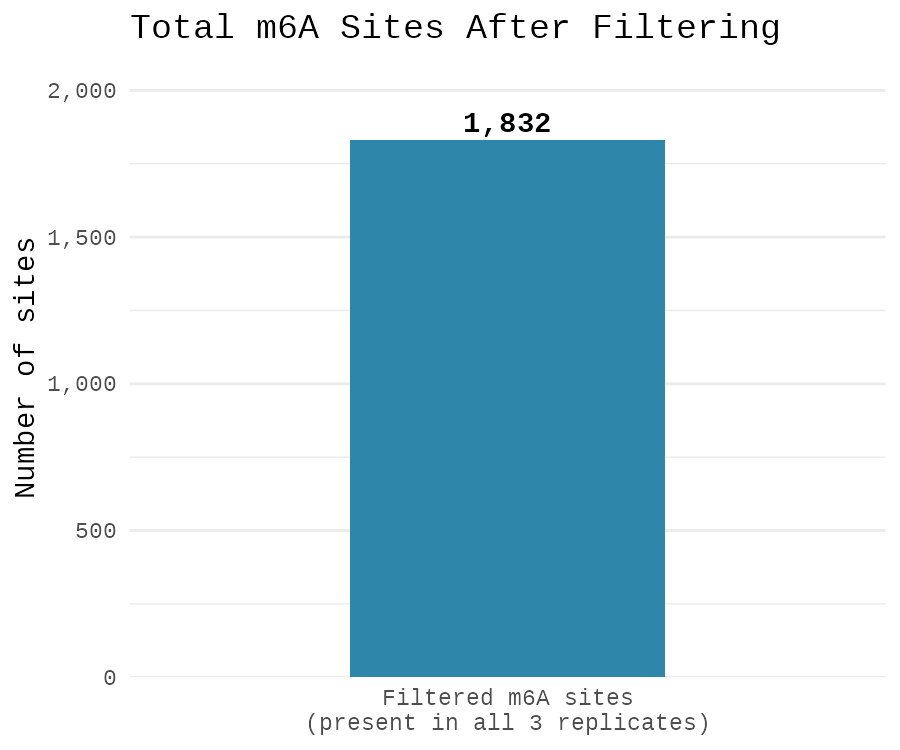

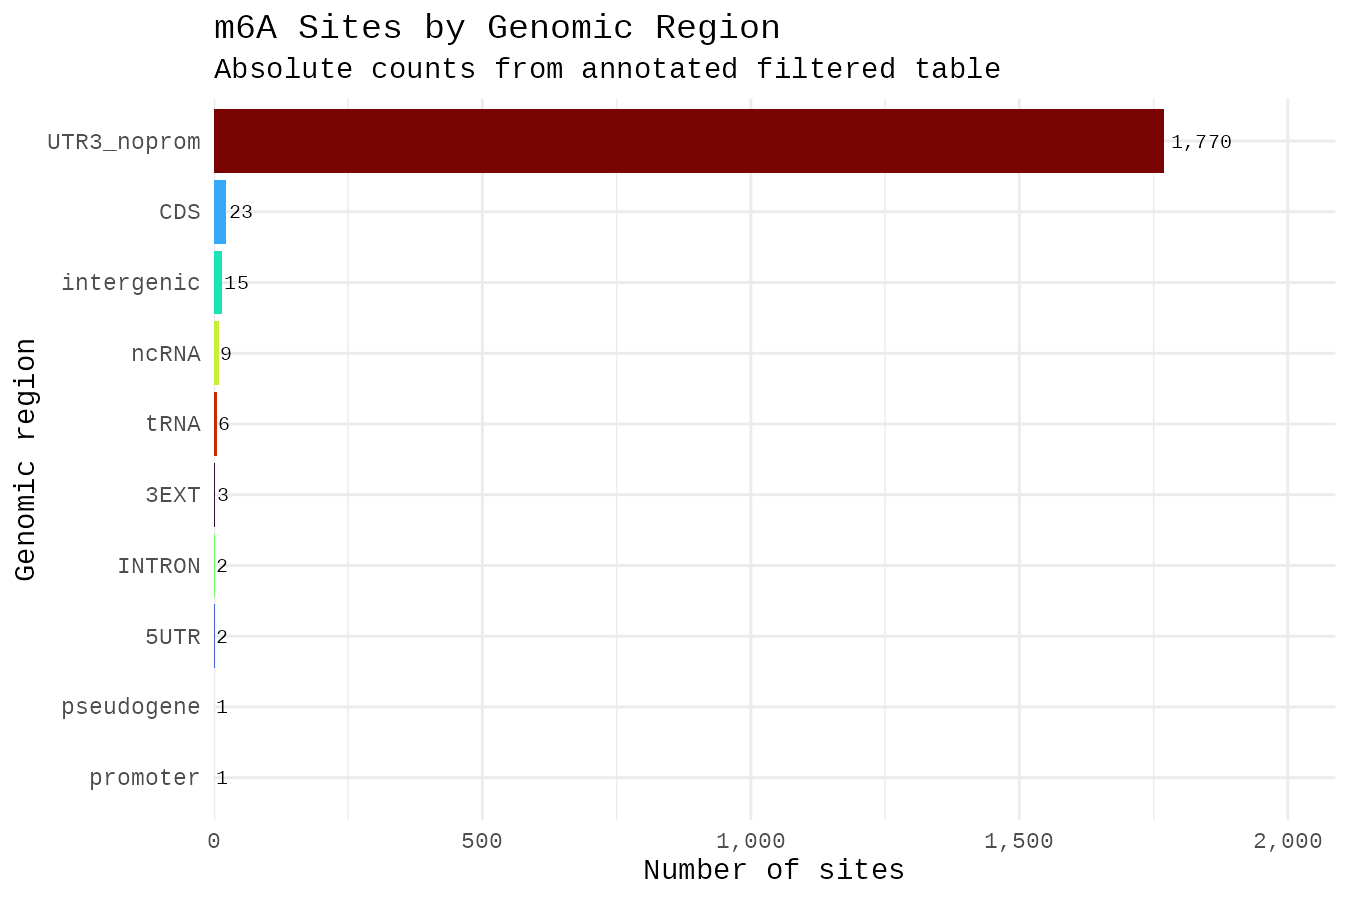

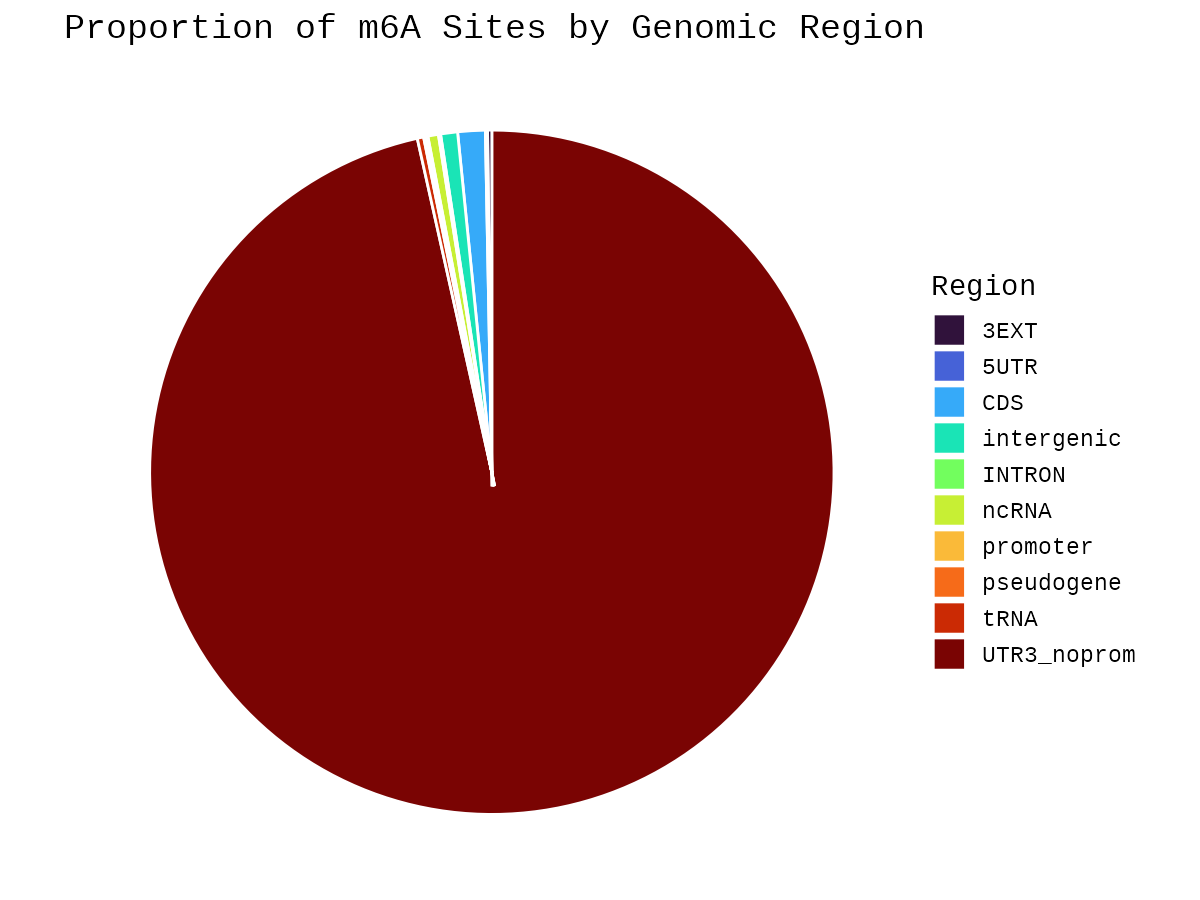

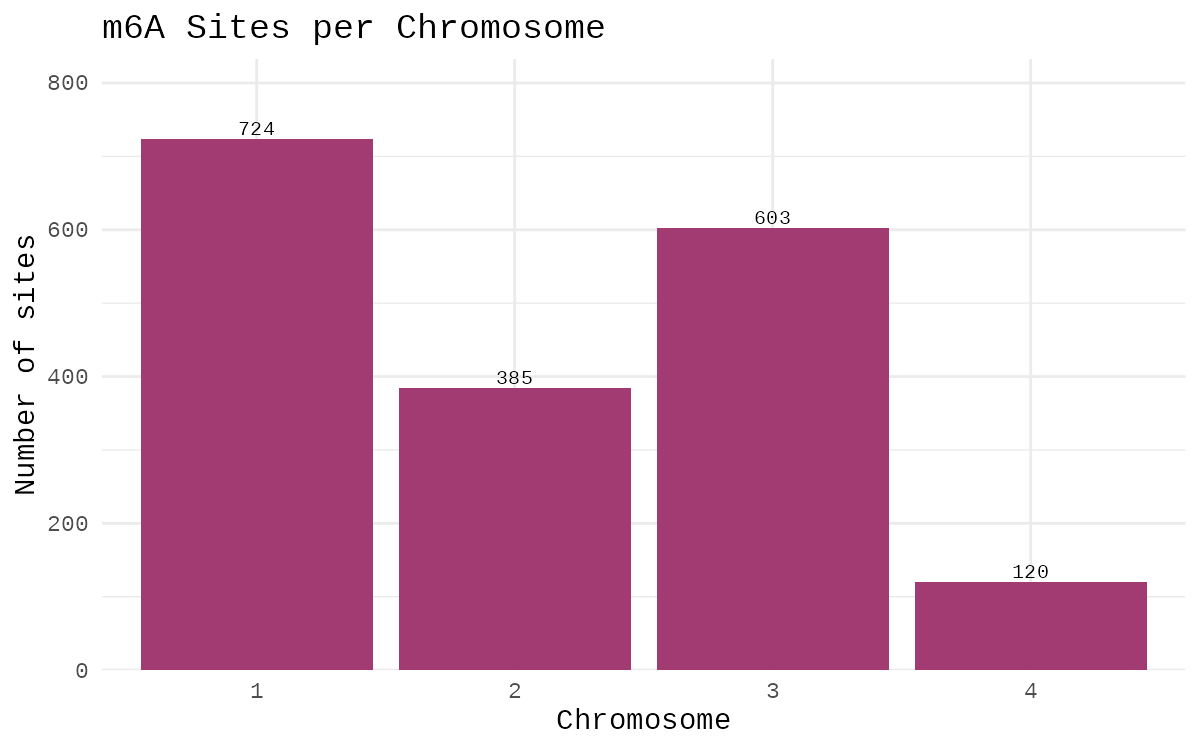

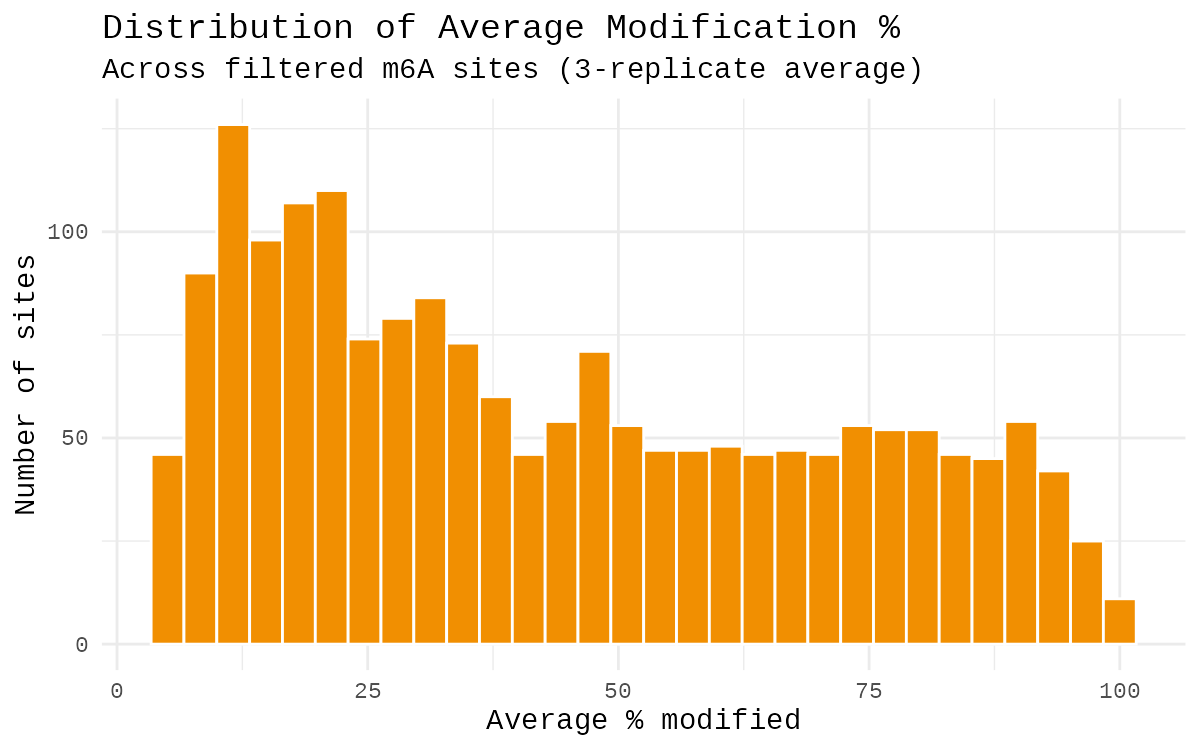

In [ ]:
from IPython.display import Image, display

display(Image("/content/01_total_m6A_sites.png"))
display(Image("/content/02_sites_by_region_counts.png"))
display(Image("/content/03_sites_by_region_percent.png"))
display(Image("/content/04_sites_by_chromosome.png"))
display(Image("/content/05_mod_percent_histogram.png"))